# Interpolación espacial

La interpolación espacial estima valores en ubicaciones no muestreadas usando datos de puntos conocidos. Por ejemplo, puedes estimar el pH del suelo entre puntos de muestreo.

## Métodos de interpolación IDW

El valor en un punto se calcula como promedio ponderado de los valores vecinos, con pesos inversamente proporcionales a la distancia.

<img src="Image/IDW.jpg" width="300" heigth="220">

### Controlar la influencia con el parámetro Potencia
IDW se basa principalmente en el inverso de la distancia elevada a una potencia matemática. El parámetro Potencia permite controlar la importancia de los puntos conocidos en los valores interpolados según su distancia al punto de salida. Es un número real positivo, y su valor predeterminado es 2.

Al definir un valor de potencia más alto, se puede dar mayor importancia a los puntos más cercanos. Por lo tanto, los datos cercanos tendrán mayor influencia y la superficie tendrá más detalle (será menos uniforme). A medida que aumenta la potencia, los valores interpolados se aproximan al valor del punto de muestra más cercano. Especificar un valor de potencia más bajo dará mayor influencia a los puntos circundantes más alejados, lo que resultará en una superficie más uniforme.

### Limitar los puntos utilizados para la interpolación
Las características de la superficie interpolada también se pueden controlar limitando los puntos de entrada utilizados en el cálculo de cada valor de celda de salida.

### Radio de búsqueda variable
Con un radio de búsqueda variable, se especifica el número de puntos utilizados para calcular el valor de la celda interpolada.

In [54]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os, glob

## Cargar datos vectoriales

In [55]:
shp_punto = glob.glob("Datos_transformados.shp")
shp_punto

['Datos_transformados.shp']

In [56]:
shp_parcela = glob.glob("zona.shp")
shp_parcela

['zona.shp']

In [57]:
# gdf_punto = gpd.read_file(shp_punto[0])
gdf_punto = gpd.read_file('Datos_transformados.shp')
gdf_parcela = gpd.read_file(shp_parcela[0])

In [58]:
gdf_punto.head(3)

,fid,ID,Arena,Arcilla,Limo,Textura,Ph,MO,N,P_ppm,...,AI,H,CICe,Bas_Camb,Ac_Camb,Sat_AI,X,Y,P_ppm_0.5,geometry
0,1,1,35,22,43,Franco,4.20,2.46,0.12,0.58,...,2.49,1.31,7.44,49,51,33,405495.08,554342.97,-0.476845,POINT (405495.08 554342.97)
1,2,2,47,20,33,Franco,4.07,2.28,0.11,2.28,...,3.07,1.53,6.97,34,66,44,405530.26,554341.22,1.019934,POINT (405530.26 554341.22)
2,3,3,23,30,47,Franco Arcillo Limoso,4.17,2.81,0.14,2.56,...,2.56,0.64,5.27,39,61,49,405585.65,554351.33,1.200000,POINT (405585.65 554351.33)


In [59]:
gdf_punto.columns

Index(['fid', 'ID', 'Arena', 'Arcilla', 'Limo', 'Textura', 'Ph', 'MO', 'N',
       'P_ppm', 'K_ppm', 'CIC', 'Ca', 'Mg', 'AI', 'H', 'CICe', 'Bas_Camb',
       'Ac_Camb', 'Sat_AI', 'X', 'Y', 'P_ppm_0.5', 'geometry'],
      dtype='object')

### Cargar el área limite del estudio

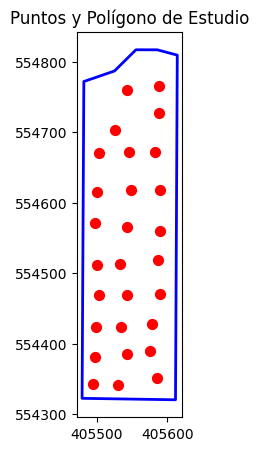

In [60]:
# Visualizar ambos datasets
fig, ax = plt.subplots(figsize=(7, 5))
gdf_parcela.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=2)
gdf_punto.plot(ax=ax, color="red", markersize=50)
plt.title("Puntos y Polígono de Estudio")
plt.show()

## Determinar el mejor potencial - power

In [9]:
!pip install scikit-learn

In [61]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from scipy.spatial import distance

### Acceder a la informacion Este, Norte y Valores PH

In [62]:
# Datos para IDW y validación cruzada
coords = gdf_punto[["X", "Y"]].values
values = gdf_punto["Ph"].values

### Lista de rango de potencias

In [63]:
import numpy as np

In [64]:
# Rango de potencias a probar
powers = np.arange(1, 6, 0.5)  # power = 1 a 5.5

In [65]:
powers

array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5])

## La herramienta Leave-One-Out Cross Validation (LOOCV)
es una técnica de validación cruzada muy exhaustiva, en geoestadística para validar interpolaciones (kriging, IDW, RBF, etc.) y calcular métricas de precisión.

#### ¿Qué es LOOCV?

Consiste en usar todos los datos menos uno para entrenar el modelo,

y luego usar ese único dato que quedó afuera como validación.

Este proceso se repite tantas veces como observaciones tengas en el dataset.

Ejemplo:

* Si tienes 100 puntos de muestreo, entonces el modelo se entrena 100 veces:

  __Cada vez deja 1 punto afuera.__

  __Se predice ese punto.__

  __Se calcula el error.__

Al final, se promedian todos los errores → esa es la métrica de desempeño del modelo.

In [66]:
# Preparar Leave-One-Out CV
loo = LeaveOneOut()
rmse_scores = []

In [67]:
for p in powers:
    y_true = []
    y_pred = []

    for train_idx, test_idx in loo.split(coords):
        train_coords, test_coord = coords[train_idx], coords[test_idx].reshape(1, -1)
        train_values, test_value = values[train_idx], values[test_idx][0]

        # Calcular distancias
        dists = distance.cdist(test_coord, train_coords)[0]

        # Evitar división por cero
        dists[dists == 0] = 1e-10  # evitar división por cero

        # Ponderación
        weights = 1 / (dists ** p)
        weights /= weights.sum()

        pred = np.dot(weights, train_values)

        y_true.append(test_value)
        y_pred.append(pred)
    # Calcular RMSE para este power
    rmse = mean_squared_error(y_true, y_pred)
    rmse_scores.append(rmse)

In [68]:
# Resultados
rmse_results = pd.DataFrame({"Power": powers, "RMSE": rmse_scores})
best_power = rmse_results.loc[rmse_results["RMSE"].idxmin(), "Power"]

In [69]:
print(rmse_results)
print("Mejor parámetro power:", best_power)

   Power      RMSE
0    1.0  0.038417
1    1.5  0.034391
2    2.0  0.032987
3    2.5  0.033044
4    3.0  0.033855
5    3.5  0.035043
6    4.0  0.036408
7    4.5  0.037833
8    5.0  0.039251
9    5.5  0.040622
Mejor parámetro power: 2.0


## Determinar el número de vecinos considerados (n_neighbors)

Este parámetro define cuántos puntos de muestreo cercanos se utilizan en el cálculo del valor interpolado. En lugar de considerar todos los puntos disponibles, IDW con vecinos limita la influencia al conjunto más próximo, lo que ofrece varias ventajas:

* Mayor eficiencia computacional al evitar cálculos innecesarios.

* Reducción del sobreajuste al ignorar puntos lejanos poco representativos.

* Control sobre el nivel de suavizado: pocos vecinos generan superficies más irregulares (capturan mejor la variabilidad local), muchos vecinos suavizan la superficie interpolada.

Por ello, es habitual aplicar validación cruzada para encontrar el valor óptimo de n_neighbors, minimizando errores como el RMSE o el MAE.

In [70]:
# CONFIGURACIÓN
# ----------------------------
power = best_power  # usar el mejor power determinado por validación cruzada

In [71]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [72]:
# Datos para IDW y validación cruzada
coords = gdf_punto[["X", "Y"]].values
values = gdf_punto["Ph"].values

In [73]:
# Valores de vecinos a probar
vecinos_lista = [3, 5, 8, 10, 15, 20]

In [74]:
# Función para realizar IDW Leave-One-Out
def idw_loocv(xy, z, power, n_neighbors):
    valores_interpolados = []
    errores = []

    for i in range(len(xy)):
        xi = xy[i]
        x_rest = np.delete(xy, i, axis=0)
        z_rest = np.delete(z, i)

        # Calcular distancias
        distancias = np.sqrt(np.sum((x_rest - xi) ** 2, axis=1))

        # Obtener índices de vecinos más cercanos
        vecinos_idx = np.argsort(distancias)[:n_neighbors]
        distancias_vecinos = distancias[vecinos_idx]
        z_vecinos = z_rest[vecinos_idx]

        # Evitar división por cero
        distancias_vecinos = np.where(distancias_vecinos == 0, 1e-12, distancias_vecinos)
        pesos = 1 / distancias_vecinos ** power

        # Interpolación IDW
        zi = np.sum(pesos * z_vecinos) / np.sum(pesos)
        valores_interpolados.append(zi)

        # Error
        errores.append(z[i] - zi)

    return np.array(valores_interpolados), np.array(errores)

In [75]:
# Guardar resultados
resultados = []

for n in vecinos_lista:
    interp, err = idw_loocv(coords, values, power=power, n_neighbors=n)

    me = np.mean(err)
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    mpe = 100 * np.mean(err / np.maximum(values, 1e-12))
    mape = 100 * np.mean(np.abs(err / np.maximum(values, 1e-12)))
    r2 = r2_score(values, interp)
    eficiencia = 100 * (1 - np.sum(err**2) / np.sum((values - np.mean(values))**2))

    resultados.append({
        'Vecinos': n,
        'ME': me,
        'RMSE': rmse,
        'MAE': mae,
        'MPE (%)': mpe,
        'MAPE (%)': mape,
        'R²': r2,
        'Eficiencia (%)': eficiencia
    })

In [76]:
# Convertir a DataFrame
df_resultados = pd.DataFrame(resultados)

In [77]:
# Mostrar ordenado por RMSE ascendente
df_resultados.sort_values(by='RMSE', inplace=True)
display(df_resultados)

,Vecinos,ME,RMSE,MAE,MPE (%),MAPE (%),R²,Eficiencia (%)
3,10,0.004787,0.179170,0.147443,-0.046291,3.463580,0.405278,40.527764
4,15,0.003421,0.179580,0.148337,-0.091009,3.490536,0.402552,40.255173
1,5,0.000225,0.179627,0.152162,-0.132526,3.572260,0.402238,40.223806
2,8,0.002891,0.180017,0.148499,-0.086370,3.487527,0.399643,39.964317
5,20,0.004510,0.180918,0.148738,-0.077390,3.502665,0.393620,39.361971
0,3,-0.004164,0.194099,0.162460,-0.256014,3.802963,0.302040,30.204005


## Determinar IDW Raster

In [78]:
best_power

np.float64(2.0)

In [79]:
# CONFIGURACIÓN
# ----------------------------
power = best_power  # usar el mejor power determinado por validación cruzada
resolucion = 1  # tamaño de pixel (en metros, para UTM)
n_neighbors = 10
search_radius = 20 # radio de busqueda metros segun area

### Generar una cuadrícula dentro del polígono
Para asegurarnos de que la interpolación se realice solo dentro del polígono, generamos una cuadrícula regular de puntos y recortamos aquellos que caen fuera del polígono.

In [80]:
from shapely.geometry import Point
import numpy as np

In [81]:
parcela_bufer = gdf_parcela.buffer(30)

In [82]:
# Definir el límite del polígono
xmin, ymin, xmax, ymax = parcela_bufer.total_bounds

In [83]:
# Generar una cuadrícula regular
x_grid = np.arange(xmin, xmax, resolucion)
y_grid = np.arange(ymin, ymax, resolucion)
x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)

In [84]:
# Convertir la cuadrícula en una lista de puntos
puntos_cuadricula = [Point(x, y) for x, y in zip(x_mesh.ravel(), y_mesh.ravel())]

In [85]:
# Crear un GeoDataFrame con los puntos de la cuadrícula
cuadricula_gdf = gpd.GeoDataFrame(geometry=puntos_cuadricula,crs="EPSG:32618")

In [86]:
# Recortar la cuadrícula con el polígono
cuadricula_recortada = cuadricula_gdf[cuadricula_gdf.intersects(parcela_bufer.union_all())]

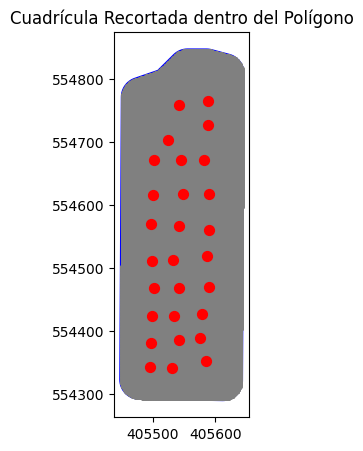

In [87]:
# Visualizar la cuadrícula recortada
fig, ax = plt.subplots(figsize=(7, 5))
parcela_bufer.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=2)
cuadricula_recortada.plot(ax=ax, color="gray", markersize=1)
gdf_punto.plot(ax=ax, color="red", markersize=50)
plt.title("Cuadrícula Recortada dentro del Polígono")
plt.show()

### Interpolación con la Distancia Inversa Ponderada (IDW)
estima valores desconocidos al especificar la distancia de búsqueda, los puntos más cercanos, el ajuste de potencia y las barreras.

In [88]:
from scipy.spatial import distance

In [89]:
# Calcular valores interpolados en la cuadrícula recortada
valores_interpolados = []
n_neighbors = 10 # Vecino mas cercano 10

In [90]:
x = gdf_punto.geometry.x.values
y = gdf_punto.geometry.y.values

In [91]:
for point in cuadricula_recortada.geometry:
    xt, yt = point.x, point.y

    # Calcular distancias a todos los puntos conocidos
    distancias = np.sqrt((x - xt)**2 + (y - yt)**2)

    # Obtener índices de los n vecinos más cercanos
    idx_vecinos = np.argsort(distancias)[:n_neighbors]

    # Filtrar distancias y valores
    distancias_vecinos = distancias[idx_vecinos]
    valores_vecinos = values[idx_vecinos]

    # Evitar división por cero
    distancias_vecinos = np.where(distancias_vecinos == 0, 1e-12, distancias_vecinos)

    # Calcular pesos IDW
    pesos = 1 / distancias_vecinos**power

    # Calcular valor interpolado
    valor_interpolado = np.sum(pesos * valores_vecinos) / np.sum(pesos)
    valores_interpolados.append(valor_interpolado)

In [92]:
len(valores_interpolados)

102847

In [93]:
cuadricula_recortada.loc[:,'Valor_IDW'] = valores_interpolados

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [94]:
len(cuadricula_recortada)

102847

In [95]:
cuadricula_recortada.dtypes

,0
geometry,geometry
Valor_IDW,float64


In [96]:
cuadricula_recortada.describe()

,Valor_IDW
count,102847.000000
mean,4.249644
std,0.176521
min,3.810025
25%,4.106146
50%,4.272589
75%,4.394106
max,4.749541


In [97]:
cuadricula_recortada.head(3)

,geometry,Valor_IDW
294,POINT (405547.058 554291.398),4.098218
295,POINT (405548.058 554291.398),4.097899
296,POINT (405549.058 554291.398),4.097590


### Visualizacion

In [98]:
type(cuadricula_recortada)

geopandas.geodataframe.GeoDataFrame

In [99]:
os.getcwd()

'/content'

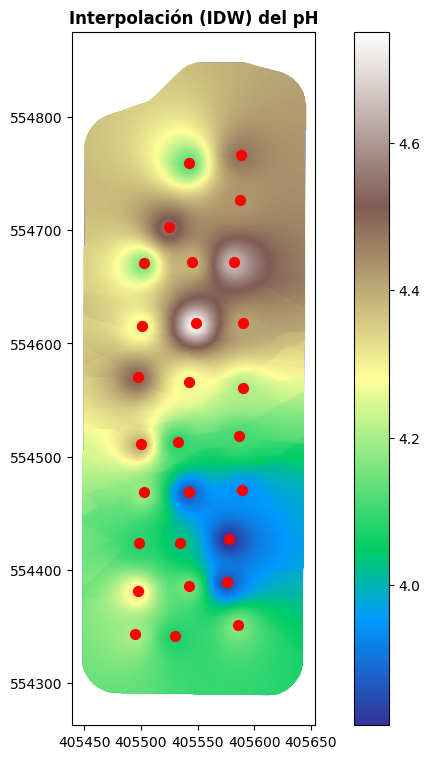

In [101]:
fig, ax = plt.subplots(figsize=(10, 9))
parcela_bufer.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=2)
# Visualizar los valores interpolados como un mapa de calor
cuadricula_recortada.plot(column='Valor_IDW',
                          ax=ax, cmap='terrain', markersize=5,
                          legend=True)
# Superponer los puntos originales
gdf_punto.plot(ax=ax, color="red", markersize=50)
plt.title("Interpolación (IDW) del pH",fontweight = "bold")
plt.savefig("grafico_interpolacion.jpg", dpi=300, bbox_inches='tight')
plt.show()


### crear un raster con los datos

In [102]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 75.3 MB/s eta 0:00:00


In [103]:
import rasterio
from rasterio.transform import from_origin
from rasterio.features import rasterize

In [104]:
# Definir resolución del raster
resolucion = 1  # Espaciado de la cuadrícula
xmin, ymin, xmax, ymax = parcela_bufer.total_bounds
ancho = int((xmax - xmin) / resolucion)
alto = int((ymax - ymin) / resolucion)

In [105]:
# Crear una transformación para el raster
transform = from_origin(xmin, ymax, resolucion, resolucion)

In [106]:
# Extraer geometrías y valores interpolados
geometrias = [(geom, valor) for geom, valor in zip(cuadricula_recortada.geometry,
                                                  cuadricula_recortada['Valor_IDW'])]

In [107]:
# Rasterizar los valores interpolados
raster_IDW = rasterize(geometrias,
                   out_shape=(alto, ancho),
                   transform=transform,
                   fill=np.nan,  # Valores fuera de la cuadrícula
                   all_touched=False,
                   dtype='float32')

In [108]:
os.getcwd()

'/content'

In [109]:
# Guardar el raster
with rasterio.open("interpolacion_IDW.tif", 'w',
                   driver='GTiff',
                   height=raster_IDW.shape[0],
                   width=raster_IDW.shape[1],
                   count=1,
                   dtype='float32',
                   crs=parcela_bufer.crs,
                   transform=transform,
                  ) as dst:
    dst.write(raster_IDW, 1)

### Validación cruzada Leave-One-Out

In [125]:
# Inicializar listas para almacenar resultados
errores = []
valores_interpolados1 = []
n_neighbors = 10

In [126]:
# Validación cruzada Leave-One-Out
for i in range(len(x)):
    # Excluir el punto actual
    x_excl = np.delete(x, i)
    y_excl = np.delete(y, i)
    valores_excl = np.delete(values, i)

    # Coordenadas del punto a interpolar
    xt, yt = x[i], y[i]

    # Calcular distancias a los puntos restantes
    distancias = np.sqrt((x_excl - xt)**2 + (y_excl - yt)**2)

    # Obtener índices de los n vecinos más cercanos
    idx_vecinos = np.argsort(distancias)[:n_neighbors]

    # Filtrar distancias y valores
    distancias_vecinos = distancias[idx_vecinos]
    valores_vecinos = values[idx_vecinos]

    # Evitar división por cero
    distancias_vecinos = np.where(distancias_vecinos == 0, 1e-12, distancias_vecinos)

    # Calcular pesos IDW
    pesos = 1 / distancias_vecinos**power

    # Calcular valor interpolado
    valor_interpolado = np.sum(pesos * valores_vecinos) / np.sum(pesos)
    valores_interpolados1.append(valor_interpolado)

    # Calcular error
    error = values[i] - valor_interpolado
    errores.append(error)

In [127]:
len(values)

28

In [128]:
len(valores_interpolados)

102847

In [129]:
len(errores)

28

In [130]:
# Convertir resultados en DataFrame
validacion = pd.DataFrame({
    'Valor_Real': values,
    'Valor_Interpolado': valores_interpolados1,
    'Error': errores,
    'Error_Absoluto': np.abs(errores)
})

In [131]:
# Mostrar resultados
print(validacion.head(29))

    Valor_Real  Valor_Interpolado     Error  Error_Absoluto
0         4.20           4.127686  0.072314        0.072314
1         4.07           4.095129 -0.025129        0.025129
2         4.17           4.072609  0.097391        0.097391
3         3.85           4.027215 -0.177215        0.177215
4         4.16           4.052960  0.107040        0.107040
5         4.32           4.137632  0.182368        0.182368
6         4.08           4.081706 -0.001706        0.001706
7         4.03           4.038881 -0.008881        0.008881
8         3.81           3.973569 -0.163569        0.163569
9         3.94           4.001757 -0.061757        0.061757
10        3.86           4.035818 -0.175818        0.175818
11        4.19           4.079580  0.110420        0.110420
12        4.40           4.206741  0.193259        0.193259
13        4.08           4.166021 -0.086021        0.086021
14        4.11           4.096762  0.013238        0.013238
15        4.20           4.241971 -0.041

In [132]:
validacion.to_excel("Validacion_IDW.xlsx")

In [133]:
#Calcular métricas de error
mae = np.mean(np.abs(errores))  # Error Absoluto Medio
rmse = np.sqrt(np.mean(np.square(errores)))  # Raíz del Error Cuadrático Medio
print(f"MAE (Error Absoluto Medio): {mae:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}")

MAE (Error Absoluto Medio): 0.1129
RMSE (Raíz del Error Cuadrático Medio): 0.1426


In [134]:
validacion.columns

Index(['Valor_Real', 'Valor_Interpolado', 'Error', 'Error_Absoluto'], dtype='object')

In [135]:
def summary_cv_idw(df, na_rm=False, tol=np.sqrt(np.finfo(float).eps)):
    """
    Calcula métricas de validación cruzada para interpolación IDW

    Parámetros:
    - df: DataFrame con columnas ['Valor_Real', 'Valor_Interpolado', 'Error']
    - na_rm: eliminar valores NaN si es True
    - tol: tolerancia para evitar divisiones por cero

    Retorna:
    - Diccionario con métricas estadísticas
    """
    obs = df['Valor_Real'].values
    pred = df['Valor_Interpolado'].values
    err = df['Error'].values

    if na_rm:
        mask = ~np.isnan(err)
        obs = obs[mask]
        pred = pred[mask]
        err = err[mask]

    # Errores porcentuales
    perr = 100 * err / np.maximum(obs, tol)

    # NSE (coef. de eficiencia de Nash-Sutcliffe)
    nse = 1 - np.sum(err ** 2) / np.sum((obs - np.mean(obs)) ** 2)
    efficiency = nse * 100

    resumen = {
        "ME (Error Medio)": np.mean(err),
        "RMSE": np.sqrt(np.mean(err ** 2)),
        "MAE": np.mean(np.abs(err)),
        "MPE": np.mean(perr),
        "MAPE": np.mean(np.abs(perr)),
        "R² (Pseudo)": 1 - np.sum(err ** 2) / np.sum((obs - np.mean(obs)) ** 2),
        "Eficiencia (%)": efficiency
    }
    return pd.DataFrame([resumen])

In [136]:
df_resumen_cv = summary_cv_idw(validacion)

In [137]:
df_resumen_cv

,ME (Error Medio),RMSE,MAE,MPE,MAPE,R² (Pseudo),Eficiencia (%)
0,0.001209,0.142632,0.112931,-0.093317,2.661277,0.62311,62.311001


In [138]:
type(df_resumen_cv)

pandas.core.frame.DataFrame

### Resumen de Validación Cruzada IDW

| Métrica                              | Valor   | Interpretación                                                                 |
|--------------------------------------|---------|--------------------------------------------------------------------------------|
| ME (Error Medio)                     | 0.001211 | Cercano a 0 indica que no hay sesgo sistemático.                              |
| RMSE (Raíz del error cuadrático medio) | 0.142631| Cuantifica el error total; penaliza más los errores grandes.                  |
| MAE (Error absoluto medio)          | 0.112929  | Promedio de los errores absolutos; robusto ante valores atípicos.            |
| MPE (Error porcentual medio)        | -0.093264  | Promedio del error relativo (%); cercano a 0 indica buen ajuste.             |
| MAPE (Error porcentual absoluto medio) | 2.661233 | Porcentaje medio absoluto del error; < 10% se considera muy bueno.            |
| R² (Pseudo)                         | 0.623116  | Proporción de varianza explicada; > 0.6 indica aceptable.              |
| Eficiencia (%)                      | 62.311558   | Nash-Sutcliffe Efficiency; >60% indica que el modelo bueno.     |


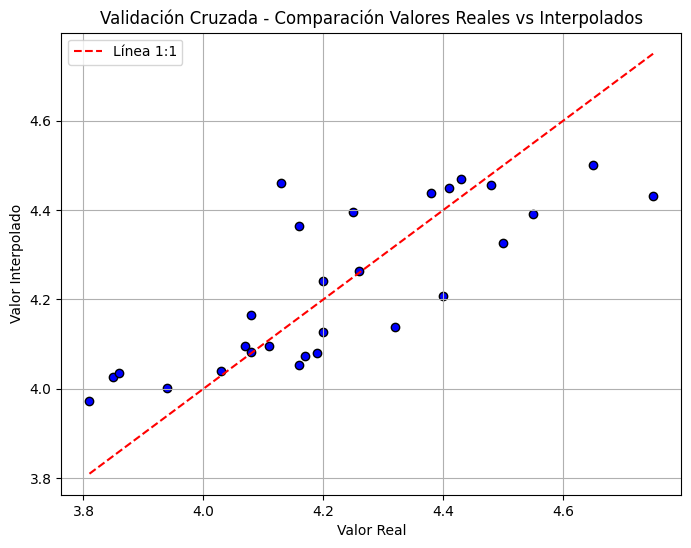

In [139]:
# Gráfico de comparación
plt.figure(figsize=(8, 6))
plt.scatter(validacion['Valor_Real'],
            validacion['Valor_Interpolado'],
            color='blue',
            edgecolor='k')
plt.plot([min(values), max(values)], [min(values), max(values)], 'r--', label="Línea 1:1")
plt.xlabel("Valor Real")
plt.ylabel("Valor Interpolado")
plt.title("Validación Cruzada - Comparación Valores Reales vs Interpolados")
plt.legend()
plt.grid()
plt.show()